# Predicting Customer Churn

"Customer churn" is a term used to describe when a company loses customers.  The example in this notebook involves a scenario familiar to many: switching mobile phone providers.  If my provider could identify my intent to switch early, it could entice me to stay with timely offers, such as a phone upgrade or a new service feature.

Machine learning can help us identify patterns in the data for customers who left in the past, thus helping us prevent the same churn in the future.

The data for this notebook is included in `churn.csv`.

# 1. Setup

Import the necessary libraries.  NOTE: If you're using an environment other than Google Colab, you may need to first install some of these using `!pip`.
*   **pandas**: A library for organizing and manipulating data, making it easy to work with tables.
*   **numpy**: A library for numerical computing in Python, providing support for large, multi-dimensional arrays and matrices, along with a collection of mathematical functions to operate on these arrays.
*   **matplotlib**: A plotting library for Python, used to create static, animated, and interactive graphs and charts.
*   **seaborn**: A statistical data visualization library built on top of matplotlib, offering a higher-level interface for drawing statistical graphics.
*   **xgboost**: An optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable, used for building machine learning models, especially for solving data science challenges involving structured data.





In [7]:
# If you need to install libraries, you can do so using this syntax
# !pip install xgboost

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# 2. Data Cleansing and Exploratory Data Analysis

It all starts with data.  Load the data from churn.csv into a DataFrame, then explore and visualize it to help us better understand what we're working with, and what will be most important to pass to the model when we train it.

In [35]:
# LOAD THE DATA

# We'll use pandas to load the CSV data into a DataFrame
# If using Google Colab, the file should be uploaded to /content folder
# PJ: To avoid confusion I renamed from churn to cust_data
cust_data = pd.read_csv('churn.csv')

In [36]:
print("Shape:", cust_data.shape)

# Get number of rows and columns separately
num_rows, num_columns = cust_data.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_columns}")

Shape: (3333, 21)
Number of rows: 3333
Number of columns: 21


In [37]:

# Display the first five rows of the dataset to understand its structure
cust_data.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [21]:
# ===============================
# CLEAN THE DATA
# ===============================

# Step 1: Check for Missing Values
# --------------------------------
# Identify any missing (NaN) values in the dataset.
# While this specific dataset has no missing values, it's good practice to check and handle them if needed.
# Options for handling missing values include:
#   - Dropping rows/columns with too many missing values
#   - Filling missing values with mean/median/mode or a placeholder
print("Missing values in each column:")
print(cust_data.isnull().sum())

# Step 2: Standardize Boolean Columns
# -----------------------------------
# Convert inconsistent boolean string representations into proper Python boolean types (True/False).
# This ensures uniform data representation, useful for modeling and analysis.

# Standardize the "Churn?" column: convert string labels to boolean values
cust_data["Churn?"] = cust_data["Churn?"].map({'False.': False, 'True.': True})

# Standardize the "Int'l Plan" column: 'yes' ➜ True, 'no' ➜ False
cust_data["Int'l Plan"] = cust_data["Int'l Plan"].map({'no': False, 'yes': True})

# Standardize the "VMail Plan" column: 'yes' ➜ True, 'no' ➜ False
cust_data["VMail Plan"] = cust_data["VMail Plan"].map({'no': False, 'yes': True})

Missing values in each column:
State             0
Account Length    0
Area Code         0
Phone             0
Int'l Plan        0
VMail Plan        0
VMail Message     0
Day Mins          0
Day Calls         0
Day Charge        0
Eve Mins          0
Eve Calls         0
Eve Charge        0
Night Mins        0
Night Calls       0
Night Charge      0
Intl Mins         0
Intl Calls        0
Intl Charge       0
CustServ Calls    0
Churn?            0
dtype: int64


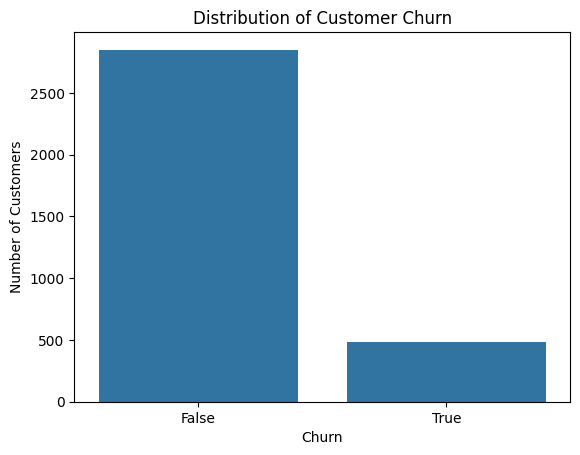

In [22]:
# ===============================
# EXPLORE AND VISUALIZE THE DATA
# ===============================

import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Visualize the Distribution of Customer Churn
# -----------------------------------------------------
# Create a count plot to show how many customers have churned vs. not churned.
# This helps understand the class balance in the target variable.
sns.countplot(x='Churn?', data=cust_data)
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

In [23]:
cust_data['Churn?']

,Churn?
0,False
1,False
2,False
3,False
4,False
...,...
3328,False
3329,False
3330,False
3331,False


In [24]:
# value_counts() gives you raw counts
cust_data['Churn?'].value_counts()

,count
Churn?,
False,2850
True,483


In [15]:
# With normalize=True, it instead gives proportions (i.e., fraction of the total)
cust_data['Churn?'].value_counts(normalize=True)

,proportion
Churn?,
False,0.855086
True,0.144914


In [25]:
# Step 2: Calculate the Percentage of Churn
# -----------------------------------------
# Calculate the normalized value counts of churned vs. non-churned customers (in percentage).
# calculates the percentage distribution of True and False values in the Churn? column
churn_percentage = cust_data['Churn?'].value_counts(normalize=True) * 100
print(churn_percentage)

Churn?
False    85.508551
True     14.491449
Name: proportion, dtype: float64


In [18]:
# Print out the percentage of customers who have churned
print(f"Percentage of customers who churned: {churn_percentage[1]:.2f}%")

Percentage of customers who churned: 14.49%


<ipython-input-18-98135d82a75e>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Percentage of customers who churned: {churn_percentage[1]:.2f}%")


There is some imbalance in the data, as only 14.49% of customers churned, but this is not extreme imbalance.

**See MY SIDEBAR 1 BELOW for imbalance criteria**

In [27]:
# Histograms for each numeric features, to see how balanced the data is
display(cust_data.describe())

,Account Length,Area Code,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [39]:
# Calculate total Account Length where churn is False and True
# Calculate total Account Length by churn status
total_account_length = cust_data.groupby('Churn?')['Account Length'].sum()

# Print the results with thousands separator
print(f"Total Account Length for non-churned (False) customers: {total_account_length['False.']:,}")
print(f"Total Account Length for churned (True) customers: {total_account_length['True.']:,}")

Total Account Length for non-churned (False) customers: 287,262
Total Account Length for churned (True) customers: 49,587


Here’s how to interpret the **histogram for the `Account Length`** column in your churn dataset:

---

### 📊 Column Summary

```text
Count    = 3333 records  
Mean     = 101  
Std Dev  = ~39.8  
Min      = 1  
25th %   = 74  
Median   = 101  
75th %   = 127  
Max      = 243
```

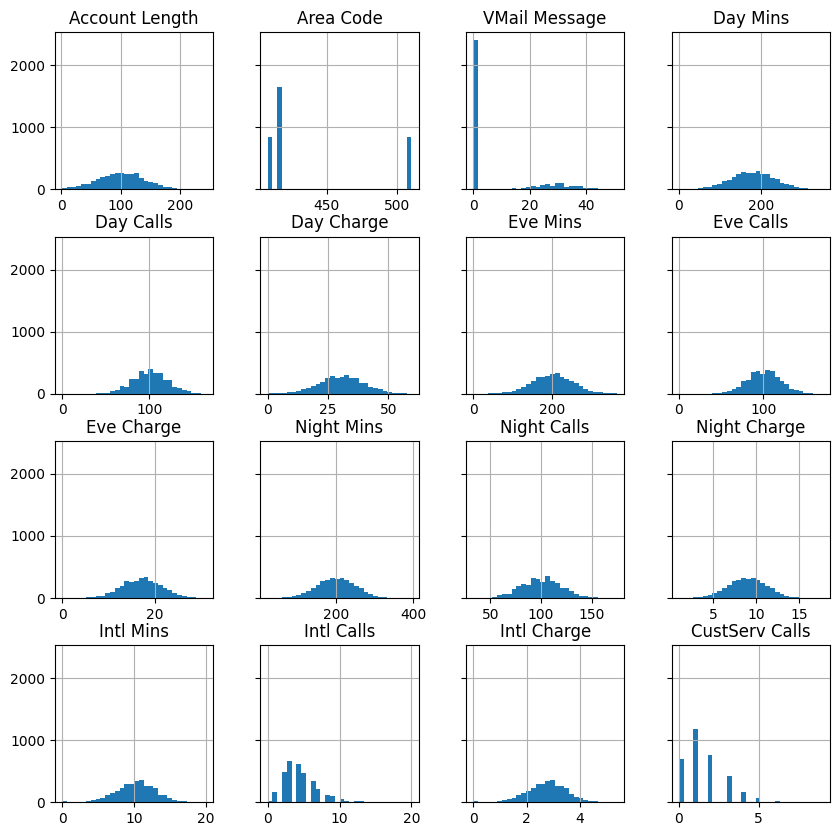

In [28]:
%matplotlib inline
hist = cust_data.hist(bins=30, sharey=True, figsize=(10, 10))



### 🧠 How to Interpret the Histogram

When you run:

```python
cust_data.hist(bins=30, sharey=True, figsize=(10, 10))
```

You’ll see a histogram for `Account Length` among other columns. For `Account Length` specifically:

- **X-axis** represents ranges of account lengths (e.g., 0–10, 10–20, ..., 230–240).
- **Y-axis** represents the number of customers in each range.

---

### 🧐 What to Look For

1. **Shape**:  
   - If the histogram is symmetric around the center (~101), it's roughly **normally distributed**.
   - If it's skewed left or right, that tells you about longer/shorter tenures being more common.

2. **Outliers**:  
   - A few customers may have extremely short (e.g., 1–10 days) or long (e.g., 230+) account lengths — the histogram helps visualize that.

3. **Central Tendency**:  
   - The tallest bars will likely be near 100, indicating many customers stayed around that long.

---

### 🛠 Example Insights You Might Derive

- If most churners have shorter account lengths, you may conclude that **early churn** is common.
- If the distribution is fairly flat, account length may not be a strong predictor of churn.
- If there's a cluster at high account lengths, those could be loyal customers.

Most numeric features are well-distributed, showing a bell-shaped (or Gaussian) distribution.  In machine learning, this normality is desired for optimal performance of the algorithms.  The exceptions are `VMail Message` and `Area Code`, which we'll handle below.

**TIP**: You are looking for Gaussian distributions.

In [40]:
# Frequency tables for each categorical feature
for column in cust_data.select_dtypes(include=['object', 'bool']).columns:
    # Using 'display' to show the DataFrame and 'pd.crosstab()' to create the frequency table
    display(column, pd.crosstab(index=cust_data[column], columns='% observations', normalize='columns') * 100)  # Multiplying by 100 to convert to percentage

'State'

col_0,% observations
State,
AK,1.560156
AL,2.400240
AR,1.650165
AZ,1.920192
CA,1.020102
CO,1.980198
CT,2.220222
DC,1.620162
DE,1.830183


'Phone'

col_0,% observations
Phone,
327-1058,0.030003
327-1319,0.030003
327-3053,0.030003
327-3587,0.030003
327-3850,0.030003
...,...
422-7728,0.030003
422-8268,0.030003
422-8333,0.030003


"Int'l Plan"

col_0,% observations
Int'l Plan,
no,90.309031
yes,9.690969


'VMail Plan'

col_0,% observations
VMail Plan,
no,72.337234
yes,27.662766


'Churn?'

col_0,% observations
Churn?,
False.,85.508551
True.,14.491449


This exploration tells us:
*   `State`: Fairly well distributed; we will check correlations later
*   `Phone`: With all the unique values, it will be hard to use this as a feature.  We should drop this, along with `Area Code`, as it goes with `Phone`.
*   `Int'l Plan`: We will  check correlations later
*   `VMail Plan`: We will check correlations later
*   `Churn`: The target feature; included here because it's a categorical feature (meaning it can take on just a fixed number of possible values)

In [ ]:
# Drop Area Code and Phone from the dataset
churn = cust_data.drop(['Phone', 'Area Code'], axis=1)

In [ ]:
# Two options to help visualize the correlation between features and Churn (heatmap and correlation matrix)
# Correlation heatmap of numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(cust_data.corr(), annot=True, fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# Calculate the correlation matrix, focusing on the Churn column
correlation_matrix = cust_data.corr()
churn_correlations = correlation_matrix["Churn?"].sort_values(ascending=False)

# Plotting the correlations with Churn
plt.figure(figsize=(8, 10))
sns.barplot(x=churn_correlations.values, y=churn_correlations.index)
plt.title("Correlation with Churn")
plt.xlabel("Correlation Coefficient")
plt.show()

churn_correlations

This exploration tells us:

*   `Int'l Plan`: There's a positive correlation (0.26) between having an international plan and churn, suggesting customers with international plans are more likely to churn. This could be due to various factors such as cost, satisfaction with international service, or other reasons that warrant further investigation.

*   `CustServ Calls`: The number of customer service calls is positively correlated (0.21) with churn, indicating that customers who contact customer service more frequently are more likely to leave. This might reflect issues with service satisfaction or unresolved problems.

*   `Day Mins` and `Day Charge`: Both of these features show a positive correlation (about 0.21) with churn, suggesting that higher day time usage (and the associated charges) could be a factor in customers' decision to churn.

*   `VMail Plan` and `VMail Message`: These features are negatively correlated with churn (-0.10 and -0.09, respectively), indicating that customers who use voicemail services are less likely to churn. This could be interpreted as an indicator of customer engagement or satisfaction with the service.

*   `Intl Calls`: Interestingly, the number of international calls is negatively correlated (-0.05) with churn, which might suggest that customers making more international calls are less likely to leave, contrasting with the positive correlation seen with having an international plan.


In [ ]:
# Scatter matrix to visualize the relationship between non-target (i.e., "Churn") features
pd.plotting.scatter_matrix(churn.select_dtypes(include=[np.number]), figsize=(12, 12), alpha=0.2)
plt.show()

This exploration tells us:


*   Some features (the ones with a diagonal line on the scatter matrix) have a correlation of 100% with one another (such as Day Charge and Day Mins, Night Charge and Night Mins)
*   Features like this can cause problems when we train the model later, so we'll remove the "Charge" features

In [ ]:
# Drop features for Day Charge, Eve Charge, Night Charge, Intl Charge to remove the 100% correlation issue
cust_data = cust_data.drop(["Day Charge", "Eve Charge", "Night Charge", "Intl Charge"], axis=1)

In [ ]:
# One-hot encode the State column so we have 0s and 1s rather than string data
churn_encoded = pd.get_dummies(churn, columns=['State'])

# 3. Building and Training the Model

In this section, we split the data into training, validation and test sets.  Then we build the model, inputting various parameters.  Finally, we train the model on the training dataset, evaluting it with the validation dataset.

In [ ]:
# Split the data into training, validation and test sets

# Randomly shuffle the dataset and split it into training (70%), validation (20%), and testing (10%) sets
train_data, validation_data, test_data = np.split(churn_encoded.sample(frac=1, random_state=1729),
                                                  [int(0.7 * len(churn)), int(0.9 * len(churn))])

In [ ]:
# Assuming the last column "Churn?" is the target variable
# Separate the features and the target variable for each dataset
X_train = train_data.drop("Churn?", axis=1)
y_train = train_data["Churn?"]
X_val = validation_data.drop("Churn?", axis=1)
y_val = validation_data["Churn?"]
X_test = test_data.drop("Churn?", axis=1)
y_test = test_data["Churn?"]

# Convert the datasets into DMatrix format for XGBoost
# XGBoost works well with DMatrix, a data structure optimized for both memory efficiency and training speed
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

In [ ]:
# Specify parameters for the model
params = {
    'max_depth': 3,  # The maximum depth of the decision tree; can be adjusted (typically ranges 3-10)
    'eta': 0.1,  # The learning rate (how much the model adjusts itself in response to errors); can be adjusted
    'objective': 'binary:logistic',  # We're choosing this because it's a binary problem (customers either churn or they don't)
                                     # Logistic means it will output a probability (the probability that a customer will leave)
    'eval_metric': 'auc',  # Evaluation metrics for validation data, e.g., "auc" or "Area Under the Curve" for binary classification
}
num_rounds = 100  # The number of rounds for boosting


In [ ]:
# Train the model using the training dataset and evaluate it using the validation dataset
evallist = [(dval, 'eval'), (dtrain, 'train')]
bst = xgb.train(params, dtrain, num_rounds, evallist)

AUC values range from 0 to 1. A model whose predictions are 100% wrong has an AUC of 0.0; one whose predictions are 100% correct has an AUC of 1.0.
AUC values between 0.5 and 1.0 indicate useful models. A value of 0.5 suggests a model that does no better than random chance.

Higher AUC values indicate better model performance. In our model, the AUC for both the evaluation set (eval-auc) and the training set (train-auc) increases over the iterations, suggesting the  model is learning and improving its ability to distinguish between the classes over time.


# 4. Evaluating the Model



Initially, the gap between training and evaluation AUC is somewhat moderate, but it starts to widen significantly as training progresses. For instance, towards the end (around iteration 99), the train-auc is at 0.97169 while the eval-auc is at 0.87690. This growing gap may suggest that the model is beginning to overfit the training data-—meaning it's getting better at predicting the training data, but not the evaluation data.  This suggests that the model is fitting more to the idiosyncrasies of the training data rather than capturing generalizable patterns that apply to unseen data.

**Actions to Consider**:

**Early Stopping**: Implement early stopping to halt the training process once the evaluation metric stops improving for a specified number of rounds. XGBoost supports early stopping.

**Regularization**: Increase regularization parameters (lambda, alpha) to penalize more complex models and thus mitigate overfitting.

**Parameter Tuning**: Adjust other hyperparameters, like max_depth, min_child_weight, and subsample, to help control model complexity and fit.

**Cross-Validation**: Use XGBoost's built-in cross-validation method to assess model performance more robustly. This might give you a better indication of how the model will perform on unseen data.

**Feature Engineering**: Revisit your features to ensure they're relevant and not leading to overfitting. Removing irrelevant or highly correlated features can sometimes improve model generalizability.

In [ ]:
# Implementing early stopping (i.e., train the model to learn from data until it stops getting better)

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,  # Set to a high number intentionally; training may stop much earlier
    evals=[(dval, "eval")],
    early_stopping_rounds=10  # Stops after 10 rounds of no improvement on the eval dataset
)

# After training, you can access the best iteration
# This is the number of the training round where the model performed the best on the validation dataset before it stopped improving
# We'll use this in the next code block
print(f"Best iteration: {bst.best_iteration}")


In [ ]:
# Make predictions with the test dataset on the final (best) model

# Predicting the probabilities for the positive class ("Churn")
y_pred_proba = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))

# The scikit-learn library is great for calculating AUC and other metrics, though this could also be calculated manually
from sklearn.metrics import roc_auc_score

# Print the final AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"Final AUC on Test Dataset: {auc_score:.3f}")

An AUC score of over 0.9 is often considered excellent in many applications. It indicates strong differentiation between the positive and negative classes in the dataset, suggesting that the model has a good predictive ability for the task at hand.

# ***MY SIDEBAR 1:***

The term **"class imbalance"** refers to how unevenly the target classes (e.g., churned vs. not churned) are distributed. In classification problems, **imbalance matters** because it can affect how well your model learns to identify minority classes.

---

### ⚖️ Criteria for Identifying Imbalance

Here are some general guidelines:

| Class Balance | Churn Example | Notes |
|---------------|---------------|-------|
| **Balanced** | ~50% churn vs. 50% no churn | Ideal but rare in real-world data. |
| **Mildly Imbalanced** | 70-30 or 80-20 | This is usually manageable without major intervention. |
| **Moderately Imbalanced** | 85-15 or 90-10 | Starting to get tricky — your model may start ignoring the minority class. |
| **Severely Imbalanced** | 95-5 or worse | Needs serious handling (e.g., resampling, weighting, anomaly detection). |

---

### 📊 In Your Case:

You have:

```python
churn_percentage = 14.49% churned
```

That’s about **85.5% didn’t churn vs. 14.5% churned**.

This falls into the **"moderately imbalanced"** range.

- ✅ It's **not extreme**, so your model will still likely learn useful patterns.
- ⚠️ But you should **monitor precision/recall/F1 score**, especially for the minority class (`churned=True`).
- 🧪 You might also explore **resampling techniques** (e.g., SMOTE or class weighting) if performance is poor.

---

### 👀 Why it matters

If you train a model on imbalanced data:
- A naïve classifier could just predict "No churn" 100% of the time and still be **85.5% accurate**.
- But it would completely fail at identifying churners — the very people you care about targeting!

Would you like to see how to handle that imbalance during modeling?